In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Load the dataset into a DataFrame
customers = pd.read_csv('Ecommerce Customers')

# 2. Explore the data
print("--- Data Head ---")
display(customers.head())

print("\n--- Data Info ---")
print(customers.info())

print("\n--- Data Description ---")
display(customers.describe())

--- Data Head ---


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None

--- Data Description ---


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [ ]:
# 3. Perform basic data cleaning
print("Missing values in each column:")
print(customers.isnull().sum())


# 4. Apply feature engineering 
numerical_features = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']

print("\nFeatures we will use for training:")
print(numerical_features)

Missing values in each column:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Features we will use for training:
['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']


In [ ]:
# 5. Prepare the data for modeling
X = customers[numerical_features]
y = customers['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (350, 4)
Testing data shape: (150, 4)


In [ ]:
# 6. Train a model
lm = LinearRegression()

lm.fit(X_train, y_train)

print("Model Coefficients:")
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
display(coeff_df)

Model Coefficients:


,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


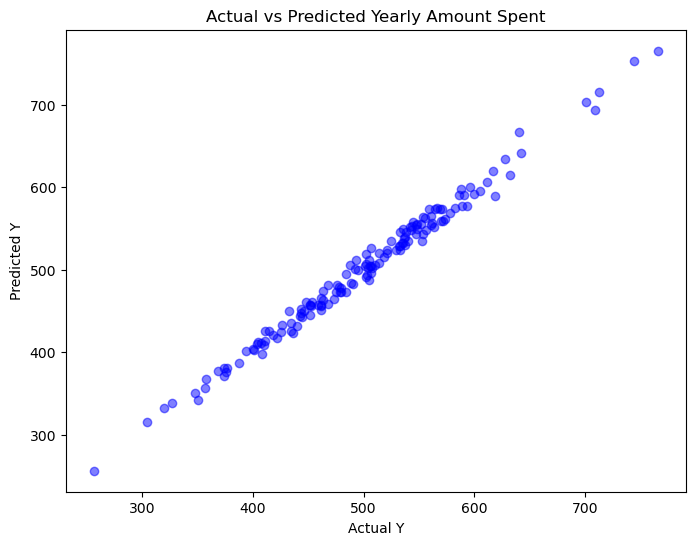

Mean Absolute Error (MAE): 7.2281486534308454
Mean Squared Error (MSE): 79.81305165097454
Root Mean Squared Error (RMSE): 8.933815066978639


In [6]:
# Make predictions on the test set
predictions = lm.predict(X_test)

# Plot real values vs predicted values to visually evaluate the model
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.title('Actual vs Predicted Yearly Amount Spent')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.show()

# 7. Evaluate the model performance mathematically
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))